# FRB cosmology constrain from $DM_{IGM} $

Highly uncertain: $\Omega_b, f_{IGM}, \chi, \omega$ (If do wCDM cosmology)

For FRB, cosmology distance is based on the dispersion measure (DM), which defined as
$$ DM=\int_0^{D_z}\frac{n_e(l)}{1+z(l)}dl $$

DM can be splitted into multiple terms:
$$ DM=DM_{MW}+DM_{halo}+DM_{IGM}+\frac{DM_{host}+DM_{src}}{1+z}$$
where $DM_{MW}$ is the DM from the Milky Way, $DM_{halo}$ is the DM from the halo, $DM_{IGM}$ is the DM from the intergalactic medium, $DM_{host}$ is the DM from the host galaxy, and $DM_{src}$ is the DM from the source.

$DM_{MW}$ can be derived from model. $DM_{halo} \sim (30-80)pc \; cm^{-3}$

Most important is the IGM component:
$$ <DM_{IGM}>=\frac{3cH_0 \Omega_b }{8\pi G m_p}\int_0^z \frac{f_{IGM}\Chi(z')(1+z')dz'}{E(z')}$$
Here,
$$\Chi=Y_H X_{e,H}+\frac{1}{2}Y_{He} X_{e,He}$$
Recall $Y_H=1/4$ and $Y_{He}=3/4$.

According to [[Bei Zhou 2014](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.89.107303)], $z\lesssim 3$, $X_{e,H}=X_{e,He}=1$; at $z\gtrsim 1.5$ $f_{IGM}\approx 90\%$; as $z\leq 0.4$ $f_{IGM}\approx (82\pm 4)\%$

H fully ionized ($\chi_{e,H}=1)$ at $ z<6 $ ([Fan 2006](https://www.annualreviews.org/content/journals/10.1146/annurev.astro.44.051905.092514)), He fully ionized ($\chi_{e,He}=1$) at $ z<2$ ([McQuinn 2009](https://ui.adsabs.harvard.edu/abs/2009ApJ...694..842M/abstract))

In [1]:
import sys
sys.path.append('../Python_scripts')
from config import *
from support import *
from cosmo_support import *

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# From DM derive redshift. Previous project analyze code.
# from scipy import integrate

# def f_IGM(z):
#     #0.84
#     return (z>1.5)*0.9+(z<=1.5)*(0.053*z+0.82) #0.83 #according to Bei Zhou 2014 paper

# def I_IGM(z,m=O_m,la=O_L):
#     return (1.+z)*f_IGM(z)/np.sqrt(m*(1.+z)**3+la)

# def f_DM(z,a=alpha):
#     Int=integrate.quad(I_IGM,0,z)[0]
#     return 30.0+a*Int+70.0/(1.+z)

# from scipy.optimize import fsolve
# def f_z(DM_MW,n=8):
#     ''' z1=0
#     z2=3
#     E=z2-z1
#     error=1/pow(10,n)
#     while E>=error/2:
#         #print([f_DM(z1),f_DM(z2)])
#         zt=(z1+z2)/2
#         ft=f_DM(zt)-DM_MW
        
#         if(ft<0):
#             z1=zt
#         elif(ft>0):
#             z2=zt
#         else:
#             z=zt
#             break
        
#         E=z2-z1
#         z=round((z1+z2)/2,n)
#         #if(z==0):
#         #    z=0.01 '''
#     return fsolve(lambda z:f_DM(z)-DM_MW,0)[0]

# load the FRB data

In [3]:
data=pd.read_csv('../data/FRB.csv')
data.head()

,FRB,z,DM_ext,From
0,FRB 20220204A,0.4012,559.43,Kritti
1,FRB 20220207C,0.0433,182.98,Kritti
2,FRB 20220208A,0.3510,346.65,Kritti
3,FRB 20220307B,0.2418,363.43,Kritti
4,FRB 20220310F,0.4780,416.71,Kritti


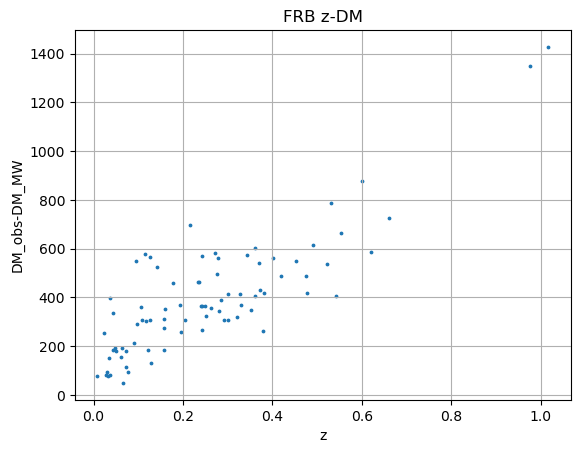

In [4]:
plt.scatter(data['z'],data['DM_ext'],s=3)  
plt.xlabel('z')
plt.ylabel('DM_obs-DM_MW')
plt.title('FRB z-DM')
plt.grid(True)
plt.show()

## The simplest case: $\chi^2$ with a single DM parameter

- For the dispersion measure:

We have contributions from the MW ${\rm DM}_{\rm MW}$, the observational limitations ${\rm DM}_{\rm obs}$, the intergalactic medium ${\rm DM}_{\rm IGM}$, the host galaxy ${\rm DM}_{\rm host}$ and potentially the source itself ${\rm DM}_{\rm host}$. Some fiducial values based on [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)] are [in pc/cm$^3$]:

$$
\sigma_{\rm MW} \sim 10, \quad \sigma_{\rm obs} \sim 1.5, \quad \sigma_{\rm IGM} \sim 100, \quad \sigma_{\rm host} \sim 30,
$$

$$
\sigma_{\rm DM_{IGM}} = \sqrt{\sigma_{\rm obs}^2+\sigma_{\rm MW}^2+\sigma_{\rm IGM}^2+\left(\frac{\sigma_{\rm host}}{1+z}\right)^2},
$$

consider uncertainty in Jun-jie Wei's paper first:

In [5]:
def sigma_DM_IGM(z, sigma_obs=1.5, sigma_MW=10, sigma_IGM=100, sigma_host=30):
    a=sigma_obs**2+sigma_MW**2+sigma_IGM**2+(sigma_host/(1+z))**2
    return np.sqrt(a)

F_fid=HUBBLE*OMEGA_BARYONS*f_IGM
print(F_fid)

2.7500474659999994


In [6]:
def DM_IGM(z, F, Om=OMEGA_MATTER, w=-1):   

    factor = 3*C_LIGHT*KM_2_MPC*F/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    integral = quad(dDM_integrand_w, 0, z, args=(Om, w))[0]
    
    unit_transform = DM_2_PCCM3
    
    DM = unit_transform*factor*integral + 80
    
    return DM

In [7]:
F_array=np.linspace(0.1,10,1000)
Chi=np.zeros_like(F_array)
sigma_vec=np.vectorize(sigma_DM_IGM)
DM_vec=np.vectorize(DM_IGM)

for idx, F in enumerate(F_array):
    DM_th=DM_vec(data['z'],F)
    sigma=sigma_vec(data['z'])
    Chi[idx]=np.sum((data['DM_ext']-DM_th)**2/sigma**2)

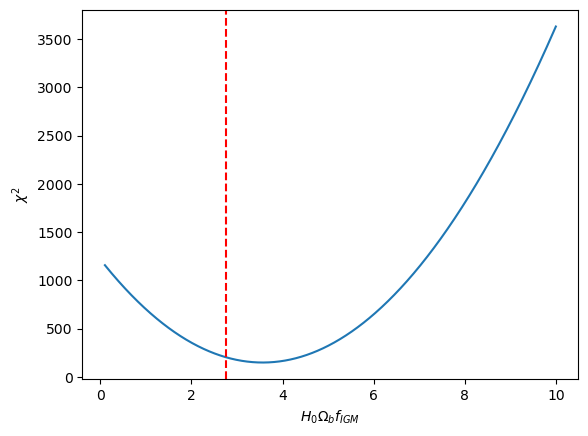

In [8]:
plt.plot(F_array, Chi)
plt.axvline(F_fid, color='r', linestyle='--')
plt.xlabel(r'$H_0 \Omega_b f_{IGM}$')
plt.ylabel(r'$\chi^2$')
plt.show()

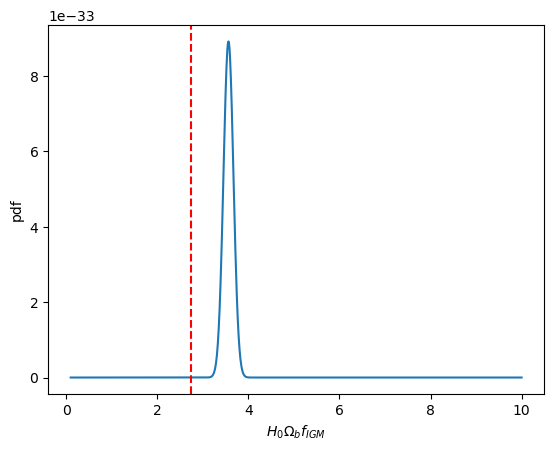

In [9]:
plt.plot(F_array, np.exp(-Chi/2))
plt.axvline(F_fid, color='r', linestyle='--')
plt.xlabel(r'$H_0 \Omega_b f_{IGM}$')
plt.ylabel(r'pdf')
plt.show()

## Macquart. 2020 reproduce

$$ DM=DM_{MW, ISM}+DM_{MW, halo}+DM_{cosmic, IGM}+DM_{host}$$

$ DM_{halo}\approx 50 pc\,cm^{-3} $

$ DM_{MW, ISM}=30 pc\,cm^{-3} $ high Galactic latitudes

$ p_{host}(DM_{host}|\mu,\sigma_{host})=\frac{1}{\sqrt{2\pi}DM \sigma_{host}}\exp\left[-\frac{(\log DM-\mu)^2}{2\sigma_{host}^2}\right] $

median value of $ \exp^\mu$ and variance $ \exp\{(\mu+\sigma_{host}^2)/2\} (\exp\{\sigma_{host}^2\}-1)^{1/2} $

Note $ DM_{host}/(1+z) $

In [10]:
def pdf_DM_host(DM, e_mu, sigma_host):
    # e^\mu with 20-200 pc cm^{-3} and \sigma_{host} in 0.2-2.0
    mu=np.log(e_mu)
    pdf=np.exp(-(np.log(DM)-mu)**2/(2*sigma_host**2))/(sigma_host*np.sqrt(2*np.pi)*DM)
    
    return pdf

/tmp/ipykernel_123702/1460587641.py:4: RuntimeWarning: divide by zero encountered in log
  pdf=np.exp(-(np.log(DM)-mu)**2/(2*sigma_host**2))/(sigma_host*np.sqrt(2*np.pi)*DM)
/tmp/ipykernel_123702/1460587641.py:4: RuntimeWarning: invalid value encountered in divide
  pdf=np.exp(-(np.log(DM)-mu)**2/(2*sigma_host**2))/(sigma_host*np.sqrt(2*np.pi)*DM)


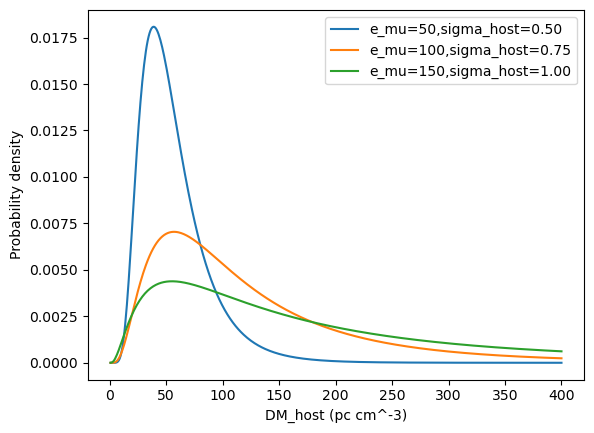

In [11]:
DM_host=np.linspace(0,400,500)
p1=pdf_DM_host(DM_host,e_mu=50,sigma_host=0.50)
p2=pdf_DM_host(DM_host,e_mu=100,sigma_host=0.75)
p3=pdf_DM_host(DM_host,e_mu=150,sigma_host=1.00)

plt.plot(DM_host,p1,label='e_mu=50,sigma_host=0.50')
plt.plot(DM_host,p2,label='e_mu=100,sigma_host=0.75')
plt.plot(DM_host,p3,label='e_mu=150,sigma_host=1.00')
plt.xlabel('DM_host (pc cm^-3)')
plt.ylabel('Probability density')
plt.legend()
plt.show()

$ p_{cosmic, IGM}(\Delta)=A\Delta^{-\beta}\exp\left(-\frac{(\Delta^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right) $

$ \sigma_{DM} $ dominated by physical variance in $DM_{cosmic}$

$\Delta=DM_{cosmic}/<DM_{cosmic}>$

$ \sigma_{DM}=Fz^{-0.5} $

Whith 3D density profile scales as $ \rho \propto r^{-\alpha} $, we have $\beta=(\alpha+1)/(\alpha-1)$

$ \alpha=3$, $\beta=3$

In [12]:
def f_sigma_DM(F, z):
    return F*z**-0.5

def pdf_DM_cosmo(DM, C_0, A, F, z, alpha=3):
    beta= alpha#(alpha+1)/(alpha-1)
    sigma_DM=f_sigma_DM(F, z)
    pdf=A*DM**(-beta)*np.exp(-(DM**(-alpha)-C_0)**2/(2*alpha**2*sigma_DM**2))
    return pdf

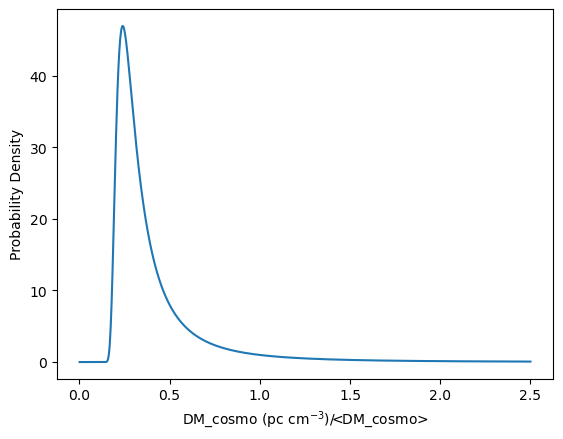

In [13]:
DM_cos=np.linspace(0.001,2.5,1000)
p=pdf_DM_cosmo(DM_cos, C_0=10, A=1, F=10, z=0.2)
plt.plot(DM_cos,p)
plt.xlabel('DM_cosmo (pc cm$^{-3}$)/<DM_cosmo>')
plt.ylabel('Probability Density')
plt.show()

Two constants still not known: $A $ and $ C_0$. According to the paper, $ C_0$ is constrain by the $ <x>=\int xp dx=1$. considering pdf, we also have $ \int p dx=1$, which help us to find $ C_0$ and $A$.

$ \int p_{cosmic, IGM}(x) dx=\int A x^{-\beta}\exp\left(-\frac{(x^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right)dx=1 $

$ \int x p_{cosmic, IGM}(x) dx=\int A x^{-\beta+1}\exp\left(-\frac{(x^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right)dx=1 $

When we do:

$ \frac{\int x p_{cosmic, IGM}(x) dx}{\int p_{cosmic, IGM}(x) dx}=\frac{\int A x^{-\beta+1}\exp\left(-\frac{(x^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right)dx}{\int A x^{-\beta}\exp\left(-\frac{(x^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right)dx}=1 $

Equavalent to: 

$ \int x \cdot p_{cosmic, IGM}(x) dx - \int p_{cosmic, IGM}(x) dx=0 $

Using this equation to do numerical calculation.

If use $ \int (x-1) p_{cosmic, IGM}(x) dx=0 $ to find C_0 will cost more time.

$A$ cancels out so we can solve for $C_0$. As for $A$, when we have $C_0$,we have:

$ A=\frac{A}{\int p_{cosmic, IGM}(x) dx}=\frac{1}{\int x^{-\beta}\exp\left(-\frac{(x^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right)dx} $

First, let's find $C_0$

In [14]:
from scipy.integrate import quad_vec

# def x_pdf_DM_cosmo(DM, C_0, A, F, z, alpha=3):
#     beta= alpha #(alpha+1)/(alpha-1)
#     sigma_DM=f_sigma_DM(F, z)
#     pdf=A*DM**(1-beta)*np.exp(-(DM**(-alpha)-C_0)**2/(2*alpha**2*sigma_DM**2))
    
#     return pdf

# def to_C_0(C_0, F, z, alpha=3):
#     #result, error = quad(integrand, 0, np.inf, args=(A, beta, alpha, C0, sigma_DM))
#     A=1
#     x_pdf, error = quad_vec(lambda x: x_pdf_DM_cosmo(x, C_0, A, F, z, alpha), 0, np.inf)
#     pdf, error = quad_vec(lambda x: pdf_DM_cosmo(x, C_0, A, F, z, alpha), 0, np.inf)
#     #print(f'x_pdf={x_pdf},pdf={pdf}')
#     try:
#         ratio=x_pdf/pdf
#     except ZeroDivisionError:
#         print(f'zero division error for x_pdf={x_pdf},pdf={pdf}')
#         ratio=50
#     except Exception as e:
#         print(f'unknown error for x_pdf={x_pdf},pdf={pdf},error={e}')
#     return ratio

# vec_C_0=np.vectorize(to_C_0)

In [15]:
# print(to_C_0(C_0=45,F=0.5,z=0.9))

In [16]:
# C=np.linspace(0.001,40,500)
# ratio=vec_C_0(C,F=0.5, z=0.2)
# plt.plot(C,ratio)
# plt.axhline(1,color='r',ls='--')
# plt.xlabel('C')
# plt.ylabel('ratio')
# plt.show()

In [17]:
from scipy.optimize import fsolve

def find_C0(F, z, alpha=3, initial_guess=1.0):
    """
    Use fsolve to find C_0 when to_C_0 = 1
    
    Parameters:
    -----------
    F: float - Structure factor parameter 
    z: float - Redshift
    alpha: float - Alpha parameter
    initial_guess: float - C_0 initial guess
    
    Returns:
    --------
    float: C_0 or None if solution not found
    """
    
    def objective_function(C_0):
        #return to_C_0(C_0[0], F, z, alpha) - 1
        A=1
        result1,_= quad(lambda x: x*pdf_DM_cosmo(x, C_0, A, F, z, alpha=3), 0, np.inf)
        result2,_= quad(lambda x: pdf_DM_cosmo(x, C_0, A, F, z, alpha=3), 0, np.inf)
        return result1-result2
    
    try:
        solution = fsolve(objective_function, [initial_guess], full_output=True)
        
        if solution[2] == 1:  # Check if solution is found
            return solution[0][0]
        else:
            print(f"find_C0 warning: F={F}, z={z}")
            return None
            
    except Exception as e:
        print(f"find_C0 error, F={F}, z={z}, error: {e}")
        return None

# Example usage
Fs = np.linspace(0.01, 0.5,10)
results = {}

for F in Fs:
    C_0 = find_C0(F=F, z=0.2)
    results[F] = C_0
    print(f"For F = {F}: C_0 = {C_0}")

For F = 0.01: C_0 = 1.0045183164070408
For F = 0.06444444444444444: C_0 = 1.2461762326530976
For F = 0.11888888888888888: C_0 = 1.6727084195353494
For F = 0.17333333333333334: C_0 = 2.0110568510984317
For F = 0.22777777777777777: C_0 = 2.2598800748232577
For F = 0.2822222222222222: C_0 = 2.4302562360462345
For F = 0.33666666666666667: C_0 = 2.530641233199334
For F = 0.3911111111111111: C_0 = 2.5672039996359968
For F = 0.44555555555555554: C_0 = 2.544560414160758
For F = 0.5: C_0 = 2.466268439524445


In [18]:
import timeit

In [19]:
print("\n Timing for Jiaming:")
%timeit find_C0(F=0.1, z=1)


 Timing for Jiaming:
24.7 ms ± 283 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


cross check

In [20]:
zs = np.linspace(0.001, 2, 100)
C_0_z = pd.DataFrame(zs, columns=['z'])

for i, z in enumerate(zs):
    C_0 = find_C0(F=0.1, z=z)
    C_0_z.loc[i, 'C_0'] = C_0
C_0_z.head()

,z,C_0
0,0.001000,-5.658269
1,0.021192,2.484595
2,0.041384,2.228710
3,0.061576,2.047243
4,0.081768,1.915944


In [21]:
C_0_z.to_csv('C_0_z_v2.csv')

Now let's try to find $A$

In [22]:
def find_A(C_0, F, z, alpha=3):
    pdf, error = quad(lambda x: pdf_DM_cosmo(x, C_0, 1, F, z, alpha), 0, np.inf)
    
    try:
        return 1/pdf
            
    except Exception as e:
        print(f"find_A error，pdf={pdf}, C_0={C_0}, F={F}, z={z}, error: {e}")
        return None

Check if correct

In [23]:
z=0.2
F=0.3

C_0=find_C0(F=F,z=z)
A=find_A(C_0=C_0,F=F,z=z)
print(fr'C_0={C_0}, A={A}')

pdf,error=quad(lambda x: pdf_DM_cosmo(x, C_0, A, F, z), 0, np.inf)
print(pdf,error)

C_0=2.4703923346339303, A=0.8281161404473844
0.9999999999999998 2.5107740454965393e-09


Show extend fig. 3. Double check.

In [24]:
DMs=np.linspace(40,1100,1000)
zs=np.array([0.1,0.2,0.5,1.0])
p_DM=pd.DataFrame(columns=zs)
F=0.15
vec_DM_cosmo=np.vectorize(pdf_DM_cosmo)

for z in zs:
    C_0=find_C0(F=F,z=z)
    A=find_A(C_0=C_0,F=F,z=z)
    DM_mean=dispersion_measure(z=z,H0=HUBBLE,Om=OMEGA_MATTER) # need larger
    p_DM[z]=DMs*vec_DM_cosmo(DM=DMs/DM_mean,A=A,z=z,C_0=C_0,F=F)

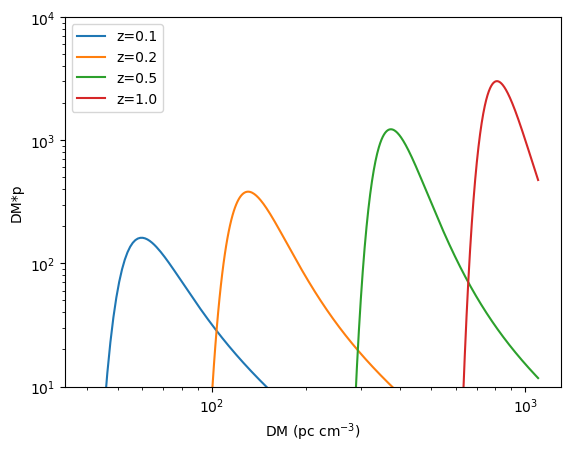

In [25]:
plt.plot(DMs,p_DM[zs[0]],label='z=0.1')
plt.plot(DMs,p_DM[zs[1]],label='z=0.2')
plt.plot(DMs,p_DM[zs[2]],label='z=0.5')
plt.plot(DMs,p_DM[zs[3]],label='z=1.0')
plt.xlabel('DM (pc cm$^{-3}$)')
plt.ylabel('DM*p')
plt.xscale('log')
plt.yscale('log')
plt.ylim(10, 10**4)
plt.legend()
plt.show()

Now let's try to find best parameters for FRBs.

No rows with DM_ < 0 found to drop


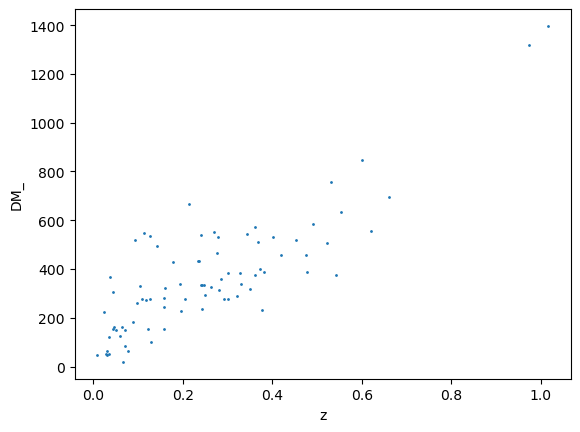

In [26]:
DM_halo=30  
# In paper is 50, but Bing suggest smaller values
# DM_ISM=30 # we already have DM_MW in data

data['DM_']=data['DM_ext']-DM_halo

dropped_rows = data[data['DM_'] < 0]

# 2. Print FRB values of dropped rows if any exist
if not dropped_rows.empty:
    print("Dropped rows:")
    print(dropped_rows[['FRB', 'DM_']])
else:
    print("No rows with DM_ < 0 found to drop")

# 3. Keep only rows where DM_ext >= 0
data = data[data['DM_'] >= 0]

plt.scatter(data['z'],data['DM_'],s=1)
plt.ylabel('DM_')
plt.xlabel('z')
plt.show()

In [27]:
data.head()

,FRB,z,DM_ext,From,DM_
0,FRB 20220204A,0.4012,559.43,Kritti,529.43
1,FRB 20220207C,0.0433,182.98,Kritti,152.98
2,FRB 20220208A,0.3510,346.65,Kritti,316.65
3,FRB 20220307B,0.2418,363.43,Kritti,333.43
4,FRB 20220310F,0.4780,416.71,Kritti,386.71


$ DM'_{FRB}=DM_{FRB}-DM_{MW, ISM}-DM_{MW, halo}=DM_{host}+DM_{cosmic} $

$ P_i(DM'_{FRB,i}|z_i)=\int_0^{DM'_{FRB,i}} p_{host}(DM_{host}|\mu, \sigma_{host})p_{cosmic}(DM'_{FRB,i}-DM_{host}, z_i)d DM_{host}$

$ \mathcal{L} = \prod_{i=1}^{N_{\text{FRBs}}} P_i(\text{DM}'_{\text{FRB}} | z_i) $


Note actually:

$ DM'_{FRB}=DM_{FRB}-DM_{MW, ISM}-DM_{MW, halo}=\frac{DM_{host}}{1+z}+DM_{cosmic} $

so:

$ P_i(DM'_{FRB,i}|z_i)=\int_0^{DM'_{FRB,i}} p_{host}(DM_{host}|\mu, \sigma_{host})p_{cosmic}(DM'_{FRB,i}-\frac{DM_{host}}{1+z_i}, z_i)d DM_{host}$

In [28]:
def DM_IGM_O_bh_70(z, O_bh_70, Om=OMEGA_MATTER ,w=-1):
    """
    Function of the DM formula, 
    eq. (12) in [arXiv:1805.12265].
    
    Input
    ----------
    z : redshift
    
    H0 : Hubble constant [km/s/Mpc]
    
    Om : Omega matter
    
    w : DE EoS parameter (w=-1 for Λ)
    
    Output
    ---------
    DM : Dispersion measure [pc/cm^3]
    """    
    
    O_bH_0=O_bh_70*70

    factor = 3*C_LIGHT*KM_2_MPC*O_bH_0*f_IGM/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    integral = quad(dDM_integrand_w, 0, z, args=(Om, w))[0]
    
    unit_transform = DM_2_PCCM3
    
    DM = unit_transform*factor*integral
    
    return DM

In [29]:
def calculate_dm_probability(DM_frb,z,F,O_bh_70,sigma_host,e_mu):
    """
    Calculate the probability of DM_FRB given various cosmological parameters
    
    Parameters:
    -----------
    DM_frb : float
        The observed DM_FRB value
    z : float
        Redshift
    F : float
        Structure factor parameter
    O_bh_70 : float
        Baryon density parameter
    sigma_host : float
        Standard deviation of host DM distribution
    e_mu : float
        Mean of host DM distribution
    
    Returns:
    --------
    float
        The calculated probability
    """

    def integrand(DM_host):
        # Calculate p_host at the current dm_host value
        p_host_val = pdf_DM_host(DM_host, e_mu, sigma_host)
        
        # Calculate p_cosmic at (DM_FRB - DM_host)
        C_0=find_C0(F=F, z=z)
        
        if C_0 is None:
            print(f"Error: find_C0 C_0 is None, when F={F}, z={z}")
            return 0.0
            
        try:
            A = find_A(C_0=C_0, F=F, z=z)
        except:
            print(f"Error: find_A, when F={F}, z={z}")
            return 0.0
        
        if A is None:
            print(f"Error: C_0={C_0} or A={A}, when F={F}, z={z}")
            return 0.0
        
        # Calculate delta parameter
        delta=(DM_frb - DM_host/(1+z))/DM_IGM_O_bh_70(z=z,O_bh_70=O_bh_70)
        p_cosmic_val = pdf_DM_cosmo(DM=delta, C_0=C_0, A=A, F=F,z=z)
        
        return p_host_val * p_cosmic_val
    
    # Perform the integration from 0 to DM_FRB
    result, error = quad_vec(integrand, 0, DM_frb)
    
    return result

In [30]:
F_array=np.linspace(0.01,0.5,5)
O_bh_70_array=np.linspace(0.015,0.095,5)
sigma_host_array=np.linspace(0.2,2.0,5)
e_mu_array=np.linspace(20,200,5)

F_4D, O_bh_70_4D, sigma_host_4D, e_mu_4D = np.meshgrid(F_array, O_bh_70_array, sigma_host_array, e_mu_array)

F_h, h_F = np.meshgrid(F_array, O_bh_70_array)
F_sigma, sigma_F = np.meshgrid(F_array, sigma_host_array)
F_e_mu, e_mu_F = np.meshgrid(F_array, e_mu_array)

h_sigma, sigma_h = np.meshgrid(O_bh_70_array, sigma_host_array)
h_e_mu, e_mu_h = np.meshgrid(O_bh_70_array, e_mu_array)

sigma_e_mu, e_mu_sigma = np.meshgrid(sigma_host_array, e_mu_array)

print(fr'Shape of F_4D: {F_4D.shape}, O_bh_70_4D: {O_bh_70_4D.shape}, sigma_host_4D: {sigma_host_4D.shape}, e_mu_4D: {e_mu_4D.shape}')
print(fr'Shape of F_h: {F_h.shape}, h_F: {h_F.shape}, F_sigma: {F_sigma.shape}, sigma_F: {sigma_F.shape}, F_e_mu: {F_e_mu.shape}, e_mu_F: {e_mu_F.shape}')

Shape of F_4D: (5, 5, 5, 5), O_bh_70_4D: (5, 5, 5, 5), sigma_host_4D: (5, 5, 5, 5), e_mu_4D: (5, 5, 5, 5)
Shape of F_h: (5, 5), h_F: (5, 5), F_sigma: (5, 5), sigma_F: (5, 5), F_e_mu: (5, 5), e_mu_F: (5, 5)


In [31]:
print(calculate_dm_probability(DM_frb=300,z=0.2,F=0.5,O_bh_70=0.015,sigma_host=0.2,e_mu=20))

0.0031676078711127932


In [32]:
import timeit

def timer_calculate_dm_probability():
    return calculate_dm_probability(DM_frb=300, z=0.2, F=0.1, O_bh_70=0.05, sigma_host=0.25, e_mu=50)

# evaluate time
execution_time = timeit.timeit(timer_calculate_dm_probability, number=1)
print(f"calculate_dm_probability time: {execution_time:.6f} seconds")

calculate_dm_probability time: 4.514023 seconds


In [33]:
# Initialize posterior_4D array for storing results
posterior_4D = np.zeros_like(F_4D)

# Iterate through all parameter combinations
for i, F in enumerate(F_array):
    for j, O_bh70 in enumerate(O_bh_70_array):
        for k, sigma_host in enumerate(sigma_host_array):
            for l, e_mu in enumerate(e_mu_array):
                # Initialize the total probability for current parameter combination
                prob_total = 1.0  # or 0.0 if you want to sum instead of multiply
               
                # Calculate and accumulate probabilities for each FRB
                for _, row in data.iterrows():
                    prob = calculate_dm_probability(
                        DM_frb=row['DM_'],     # Use DM_ column as DM_frb
                        z=row['z'],            # Use z column as redshift
                        F=F,                   # Structure factor from parameter space
                        O_bh_70=O_bh70,        # Baryon density from parameter space
                        sigma_host=sigma_host, # Host DM standard deviation from parameter space
                        e_mu=e_mu             # Host DM mean from parameter space
                    )
                    # Accumulate probability (multiply or add)
                    prob_total *= prob  # or prob_total += prob
                
                # Store the accumulated result in posterior_4D
                posterior_4D[i,j,k,l] = prob_total
                
            print(f"i,j,k,l,posterior = {i},{j},{k},{l},{posterior_4D[i,j,k,l]}",end='\r')

KeyboardInterrupt: 

Understand PDF, CDF, PPF for chi2

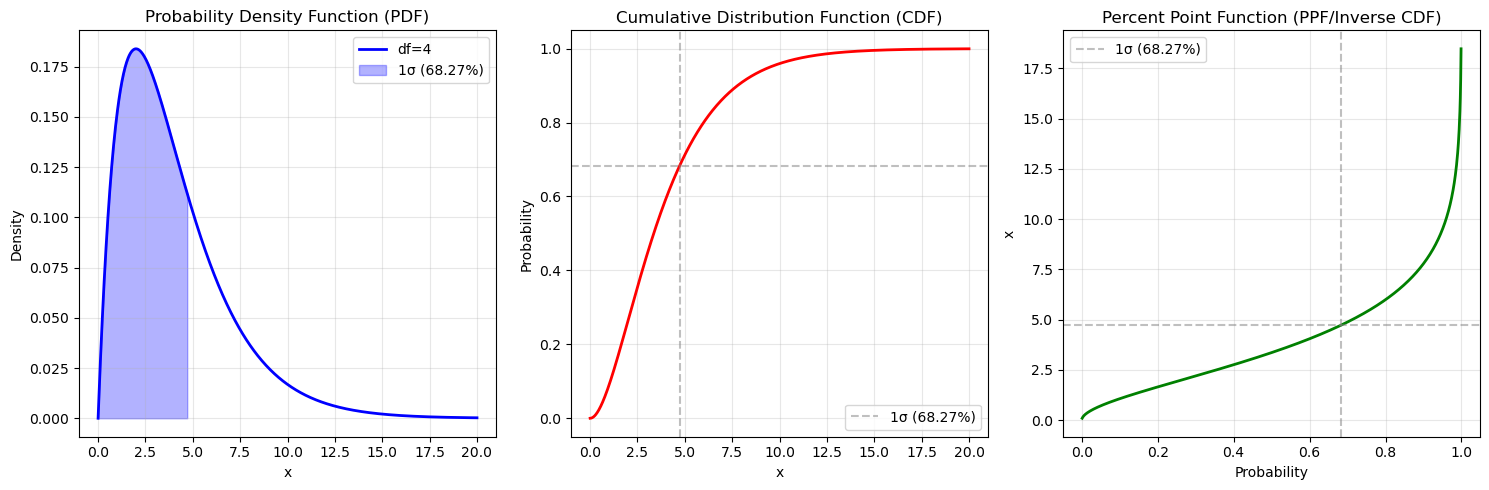


Critical values for different sigma levels (df=4):
1σ (68.27%): 4.720
2σ (95.45%): 9.716
3σ (99.73%): 16.251


In [34]:
from scipy import stats

# Create figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Generate x values for plotting
x = np.linspace(0, 20, 1000)
p = np.linspace(0.001, 0.999, 1000)  # for PPF, avoid 0 and 1

# Plot PDF (Probability Density Function)
df = 4  # degrees of freedom
pdf = stats.chi2.pdf(x, df)
ax1.plot(x, pdf, 'b-', lw=2, label=f'df={df}')
ax1.fill_between(x, pdf, where=(x <= stats.chi2.ppf(0.6827, df)), 
                 alpha=0.3, color='blue', label='1σ (68.27%)')
ax1.set_title('Probability Density Function (PDF)')
ax1.set_xlabel('x')
ax1.set_ylabel('Density')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot CDF (Cumulative Distribution Function)
cdf = stats.chi2.cdf(x, df)
ax2.plot(x, cdf, 'r-', lw=2)
ax2.axhline(y=0.6827, color='gray', linestyle='--', alpha=0.5, label='1σ (68.27%)')
ax2.axvline(x=stats.chi2.ppf(0.6827, df), color='gray', linestyle='--', alpha=0.5)
ax2.set_title('Cumulative Distribution Function (CDF)')
ax2.set_xlabel('x')
ax2.set_ylabel('Probability')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot PPF (Percent Point Function / Inverse CDF)
ppf = stats.chi2.ppf(p, df)
ax3.plot(p, ppf, 'g-', lw=2)
ax3.axvline(x=0.6827, color='gray', linestyle='--', alpha=0.5, label='1σ (68.27%)')
ax3.axhline(y=stats.chi2.ppf(0.6827, df), color='gray', linestyle='--', alpha=0.5)
ax3.set_title('Percent Point Function (PPF/Inverse CDF)')
ax3.set_xlabel('Probability')
ax3.set_ylabel('x')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Adjust layout
plt.tight_layout()
plt.show()

# Print some key values
sigma_levels = [0.6827, 0.9545, 0.9973]  # 1σ, 2σ, 3σ
print("\nCritical values for different sigma levels (df=4):")
for i, level in enumerate(sigma_levels, 1):
    critical_value = stats.chi2.ppf(level, df)
    print(f"{i}σ ({level*100:.2f}%): {critical_value:.3f}")

Draw contour plot, based on AI answer. 

In [35]:
from scipy import stats

def calculate_D(posterior_4D):
    """
    Calculate likelihood ratio test statistic D
    
    Parameters:
    -----------
    posterior_4D : numpy.ndarray
        4D array containing likelihood values (L in the equation)
    
    Returns:
    --------
    D_4D : numpy.ndarray
        4D array containing D statistic values calculated as -2ln(L/L_max)
    """
    L_max = np.max(posterior_4D)
    D_4D = -2 * (np.log(posterior_4D) - np.log(L_max))
    return D_4D

def get_sigma_thresholds():
    """
    Calculate threshold values for 1σ, 2σ, and 3σ confidence levels using chi-square distribution
    
    Returns:
    --------
    list
        Three threshold values corresponding to:
        1σ (68.27%), 2σ (95.45%), 3σ (99.73%) confidence levels
    """
    confidence_levels = [0.6827, 0.9545, 0.9973]
    thresholds = [stats.chi2.ppf(cl, df=4) for cl in confidence_levels]
    return thresholds

def plot_contours(D_4D, param1_grid, param2_grid, param1_name, param2_name, 
                 param_indices):
    """
    Plot 2D contours showing 1σ, 2σ, and 3σ confidence regions for given parameters
    
    Parameters:
    -----------
    D_4D : numpy.ndarray
        4D array of D statistic values
    param1_grid, param2_grid : numpy.ndarray
        2D meshgrid arrays for the two parameters to plot
    param1_name, param2_name : str
        Names of parameters for axis labels
    param_indices : tuple
        Indices of the two parameters in the original 4D array (0-based)
        These indices determine which dimensions to marginalize over
    """
    # Determine which dimensions need to be marginalized
    all_dims = set(range(4))
    plot_dims = set(param_indices)
    marginalize_dims = tuple(all_dims - plot_dims)
    
    # Marginalize over other dimensions by taking the minimum D value
    # This effectively finds the best-fit values for the marginalized parameters
    D_2D = np.min(D_4D, axis=marginalize_dims)
    
    # Transpose D_2D if necessary to match the parameter grid orientations
    # This ensures the axes of D_2D match the orientations of param1_grid and param2_grid
    if param_indices[0] > param_indices[1]:
        D_2D = D_2D.T
    
    # Get thresholds for different sigma levels
    thresholds = get_sigma_thresholds()
    
    # Create the figure
    plt.figure(figsize=(8, 6))
    
    # Plot filled contours for each confidence level
    colors = ['lightblue', 'lightgreen', 'pink']
    labels = ['1σ (68.27%)', '2σ (95.45%)', '3σ (99.73%)']
    
    for i, (threshold, color, label) in enumerate(zip(thresholds, colors, labels)):
        # Draw contour lines with different line styles
        plt.contour(param1_grid, param2_grid, D_2D, levels=[threshold], 
                   colors='k', linestyles=['-', '--', ':'][i])
        # Fill regions within contours
        plt.contourf(param1_grid, param2_grid, D_2D, levels=[0, threshold],
                    colors=[color], alpha=0.3, label=label)
    
    plt.xlabel(param1_name)
    plt.ylabel(param2_name)
    plt.title('Confidence Regions (1σ, 2σ, 3σ)')
    plt.legend()

# Define parameter order in the 4D array
# This maps parameter names to their corresponding indices in D_4D
PARAM_ORDER = {
    'F': 0,
    'Ω_bh_70': 1,
    'σ_host': 2,
    'μ': 3
}

# Main execution code
D_4D = calculate_D(posterior_4D)

# Define parameter pairs to plot with their corresponding indices
parameter_pairs = [
    # (param1_grid, param2_grid, param1_name, param2_name, (param1_index, param2_index))
    (F_h, h_F, 'F', 'Ω_bh_70', (PARAM_ORDER['F'], PARAM_ORDER['Ω_bh_70'])),
    (F_sigma, sigma_F, 'F', 'σ_host', (PARAM_ORDER['F'], PARAM_ORDER['σ_host'])),
    (F_e_mu, e_mu_F, 'F', 'μ', (PARAM_ORDER['F'], PARAM_ORDER['μ'])),
    (h_sigma, sigma_h, 'Ω_bh_70', 'σ_host', (PARAM_ORDER['Ω_bh_70'], PARAM_ORDER['σ_host'])),
    (h_e_mu, e_mu_h, 'Ω_bh_70', 'μ', (PARAM_ORDER['Ω_bh_70'], PARAM_ORDER['μ'])),
    (sigma_e_mu, e_mu_sigma, 'σ_host', 'μ', (PARAM_ORDER['σ_host'], PARAM_ORDER['μ']))
]

# Plot all parameter combinations
for param1_grid, param2_grid, param1_name, param2_name, param_indices in parameter_pairs:
    plot_contours(D_4D, param1_grid, param2_grid, param1_name, param2_name, param_indices)
    plt.show()

# MCMC method

In [36]:
data.head()

,FRB,z,DM_ext,From,DM_
0,FRB 20220204A,0.4012,559.43,Kritti,529.43
1,FRB 20220207C,0.0433,182.98,Kritti,152.98
2,FRB 20220208A,0.3510,346.65,Kritti,316.65
3,FRB 20220307B,0.2418,363.43,Kritti,333.43
4,FRB 20220310F,0.4780,416.71,Kritti,386.71


In [37]:
import numpyro
import numpyro.distributions as dist
from numpyro import sample
import jax.numpy as jnp
from jax import vmap, jit
import jax
from jax.scipy.special import erf

In [38]:
@jit
def pdf_DM_host_jax(DM, e_mu, sigma_host):
    """
    Calculate the probability density function for host DM
    
    Args:
        DM: Host dispersion measure
        e_mu: Mean of log-normal distribution
        sigma_host: Standard deviation of host DM distribution
    
    Returns:
        Probability density value
    """
    mu = jnp.log(e_mu)
    pdf = jnp.exp(-(jnp.log(DM) - mu)**2 / (2 * sigma_host**2)) / (sigma_host * jnp.sqrt(2 * PI) * DM)
    return pdf

@jit
def f_sigma_DM_jax(F, z):
    """
    Calculate sigma_DM as function of redshift
    
    Args:
        F: Structure factor parameter
        z: Redshift
    
    Returns:
        sigma_DM value
    """
    return F * z**-0.5

@jit
def pdf_DM_cosmo_jax(DM, C_0, A, F, z, alpha=3.0):
    """
    Calculate the probability density function for cosmological DM
    
    Args:
        DM: Dispersion measure
        C_0: C_0 parameter
        A: Normalization factor
        F: Structure factor
        z: Redshift
        alpha: Alpha parameter (default: 3.0)
    
    Returns:
        Probability density value
    """
    beta = alpha #(alpha + 1) / (alpha - 1)
    sigma_DM = f_sigma_DM_jax(F, z)
    pdf = A * DM**(-beta) * jnp.exp(-(DM**(-alpha) - C_0)**2 / (2 * alpha**2 * sigma_DM**2))
    return pdf

In [39]:
@jit
def integrate_pdf_cosmo(C_0, A, F, z, alpha=3.0):
    """
    Numerical integration of pdf_DM_cosmo
    """
    # Use a reasonable range for integration
    x = jnp.logspace(-3, 5, 1000) # from 1/10 to 10**3
    dx = x[1:] - x[:-1]
    
    # Calculate pdf values
    pdf_values = pdf_DM_cosmo_jax(x, C_0, A, F, z, alpha)
    # Calculate x*pdf values
    x_pdf_values = x * pdf_values
    
    # Compute integrals using trapezoidal rule
    integral_pdf = jnp.sum(0.5 * (pdf_values[1:] + pdf_values[:-1]) * dx)
    integral_x_pdf = jnp.sum(0.5 * (x_pdf_values[1:] + x_pdf_values[:-1]) * dx)
    
    return integral_pdf, integral_x_pdf

@jit
def c0_objective(C_0, F, z, alpha=3.0):
    """
    Objective function for finding C_0: int(x*p(x)dx) - int(p(x)dx) = 0
    """
    # Use A=1 initially since it's just a scaling factor
    integral_pdf, integral_x_pdf = integrate_pdf_cosmo(C_0, 1.0, F, z, alpha)
    return integral_x_pdf - integral_pdf

@jit
def find_c0_jax(F, z, alpha=3.0, num_iterations=200):
    """
    Find C_0 using fixed-point iteration
    """
    # Initial guess
    c0 = 0
    learning_rate = 0.1
    
    def body_fun(i, c0):
        obj_val = c0_objective(c0, F, z, alpha)
        # Update C_0 using gradient descent
        c0 = c0 - learning_rate * obj_val
        return c0
    
    c0 = jax.lax.fori_loop(0, num_iterations, body_fun, c0)
    return c0

@jit
def find_a_jax(C_0, F, z, alpha=3.0):
    """
    Find normalization factor A
    """
    # Calculate integral with A=1
    integral_pdf, _ = integrate_pdf_cosmo(C_0, 1.0, F, z, alpha)
    # A should be 1/integral
    return 1.0 / integral_pdf

@jit
def DM_IGM_O_bh_70_jax(z, O_bh_70, Om=OMEGA_MATTER, w=-1.0):
    """
    Calculate IGM DM contribution
    
    Args:
        z: Redshift
        O_bh_70: Baryon density parameter
        Om: Omega matter (default: OMEGA_MATTER)
        w: Dark energy EoS parameter (default: -1.0)
    
    Returns:
        IGM DM value
    """
    O_bH_0 = O_bh_70 * 70
    factor = 3 * C_LIGHT * KM_2_MPC * O_bH_0 * f_IGM / (8 * PI * G_NEWTON * M_PROTON) * (7/8)
    
    # Simplified integration for JAX compatibility
    # Note: This is an approximation of the original quad integration

    x = jnp.linspace(0, z, 1000)
    dx = x[1] - x[0]
    integrand = (1+x) / jnp.sqrt(Om * (1 + x)**3 + (1 - Om) * (1 + x)**(3 * (1 + w)))
    integral = jnp.sum(integrand) * dx
    
    return DM_2_PCCM3 * factor * integral

In [40]:
@jit
def calculate_dm_probability_jax(DM_frb, z, F, O_bh_70, sigma_host, e_mu):
    """
    Calculate the probability of DM_FRB given various cosmological parameters
    """
    # Find C_0 and A
    C_0 = find_c0_jax(F, z)
    A = find_a_jax(C_0, F, z)
    
    # Parameters for numerical integration
    DM_host_values = jnp.linspace(0, DM_frb, 1000)
    dDM = DM_host_values[1] - DM_host_values[0]
    
    # Calculate host contribution
    p_host = pdf_DM_host_jax(DM_host_values, e_mu, sigma_host)
    
    # Calculate delta parameter
    delta = (DM_frb - DM_host_values/(1 + z)) / DM_IGM_O_bh_70_jax(z=z, O_bh_70=O_bh_70)
    
    # Calculate cosmic contribution
    p_cosmic = pdf_DM_cosmo_jax(delta, C_0, A, F, z)
    
    # Numerical integration
    integrand = p_host * p_cosmic
    result = jnp.sum(integrand) * dDM
    
    return result

# Vectorized version for batch processing
batch_calculate_dm_probability = vmap(calculate_dm_probability_jax, in_axes=(0, 0, None, None, None, None))

In [41]:
def frb_model(data):
    # proior
    F = sample("F", dist.Uniform(F_array.min(), F_array.max()))
    O_bh_70 = sample("O_bh_70", dist.Uniform(O_bh_70_array.min(), O_bh_70_array.max()))
    sigma_host = sample("sigma_host", dist.Uniform(sigma_host_array.min(), sigma_host_array.max()))
    e_mu = sample("e_mu", dist.Uniform(e_mu_array.min(), e_mu_array.max()))
    
    # use vmap to calculate the probability of each FRB
    def prob_single_frb(frb_data):
        return calculate_dm_probability_jax(
            DM_frb=frb_data['DM_'],
            z=frb_data['z'],
            F=F,
            O_bh_70=O_bh_70,
            sigma_host=sigma_host,
            e_mu=e_mu
        )
    
    # Change the data format to a dictionary
    frb_data_dict = {
        'DM_': jnp.array(data['DM_']),
        'z': jnp.array(data['z'])
    }
    
    # Calculate the probability of each FRB using vmap
    log_probs = vmap(prob_single_frb)(frb_data_dict)
    total_log_prob = jnp.sum(jnp.log(log_probs))
    
    # Set the observation likelihood
    numpyro.factor("obs", total_log_prob)

In [42]:
# Setup the MCMC sampler
def run_mcmc(data, num_warmup=1000, num_samples=2000, num_chains=2):
    kernel = numpyro.infer.NUTS(frb_model)
    mcmc = numpyro.infer.MCMC(
        kernel,
        num_warmup=num_warmup,
        num_samples=num_samples,
        num_chains=num_chains
    )
    
    mcmc.run(jax.random.PRNGKey(0), data=data)
    return mcmc

# Usage example
if __name__ == "__main__":
    numpyro.set_host_device_count(2)
    
    mcmc = run_mcmc(data)
    
    # retrieve the samples
    %time samples = mcmc.get_samples()
    
    mcmc.print_summary()

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

CPU times: user 7 µs, sys: 0 ns, total: 7 µs
Wall time: 10.3 µs

                  mean       std    median      5.0%     95.0%     n_eff     r_hat
           F      0.16      0.02      0.16      0.14      0.18      1.00 1035489.20
     O_bh_70      0.05      0.00      0.05      0.05      0.05       nan 994666.30
        e_mu    122.32     45.89    122.32     76.43    168.20       nan 2454070.91
  sigma_host      0.97      0.31      0.97      0.66      1.28      1.00 2032493.07

Number of divergences: 4000


In [43]:
import corner
from matplotlib.colors import LogNorm
import arviz as az

In [44]:
inf_data = az.from_numpyro(mcmc)
az.summary(inf_data)

/home/zhuge/miniconda3/lib/python3.10/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/zhuge/miniconda3/lib/python3.10/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
F,0.157,0.021,0.136,0.178,0.015,0.013,2.0,2.0,4876400.29
O_bh_70,0.048,0.002,0.046,0.051,0.002,0.001,2.0,2.0,4876400.29
e_mu,122.317,45.891,76.432,168.202,32.385,27.421,2.0,2.0,4876400.29
sigma_host,0.969,0.306,0.663,1.275,0.216,0.183,2.0,2.0,4876400.29


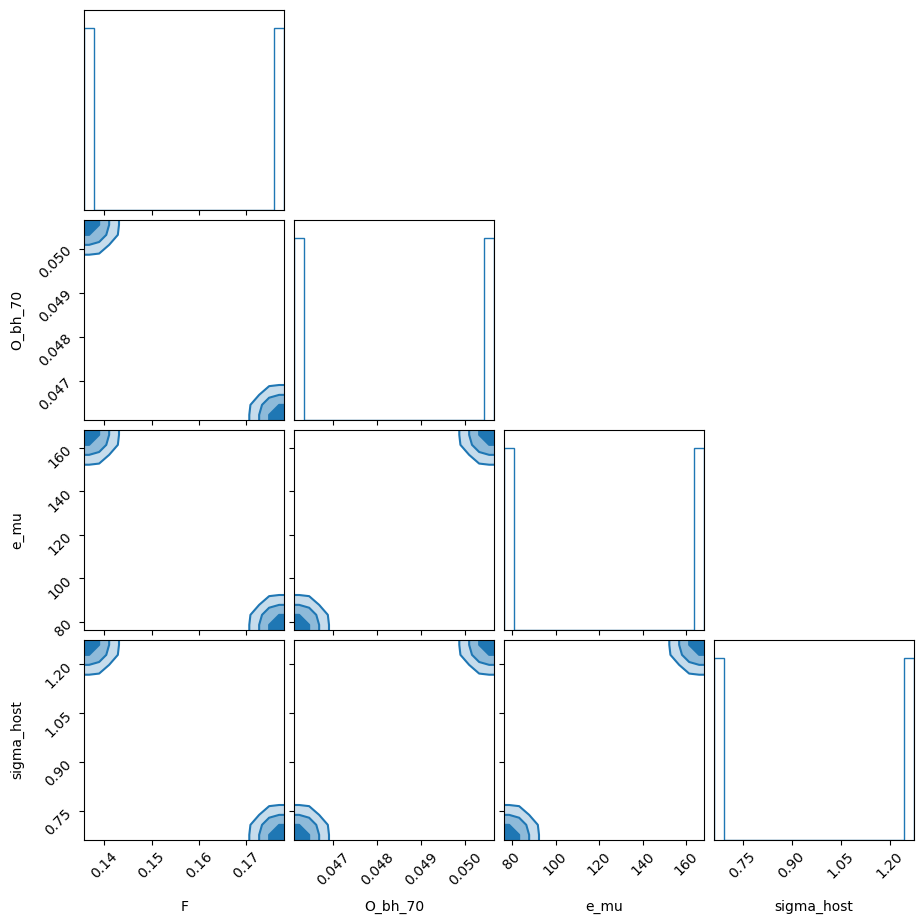

In [45]:
figure = corner.corner(
    inf_data, 
    # truths={"F": F, "O_bh_70": O_bh_70, "e_mu":e_mu, "sigma_host": sigma_host}, 
    smooth=True, 
    fill_contours=True, 
    color='tab:blue', 
    truth_color='tab:red', 
    levels=(0.68, 0.95, 0.99)
    )

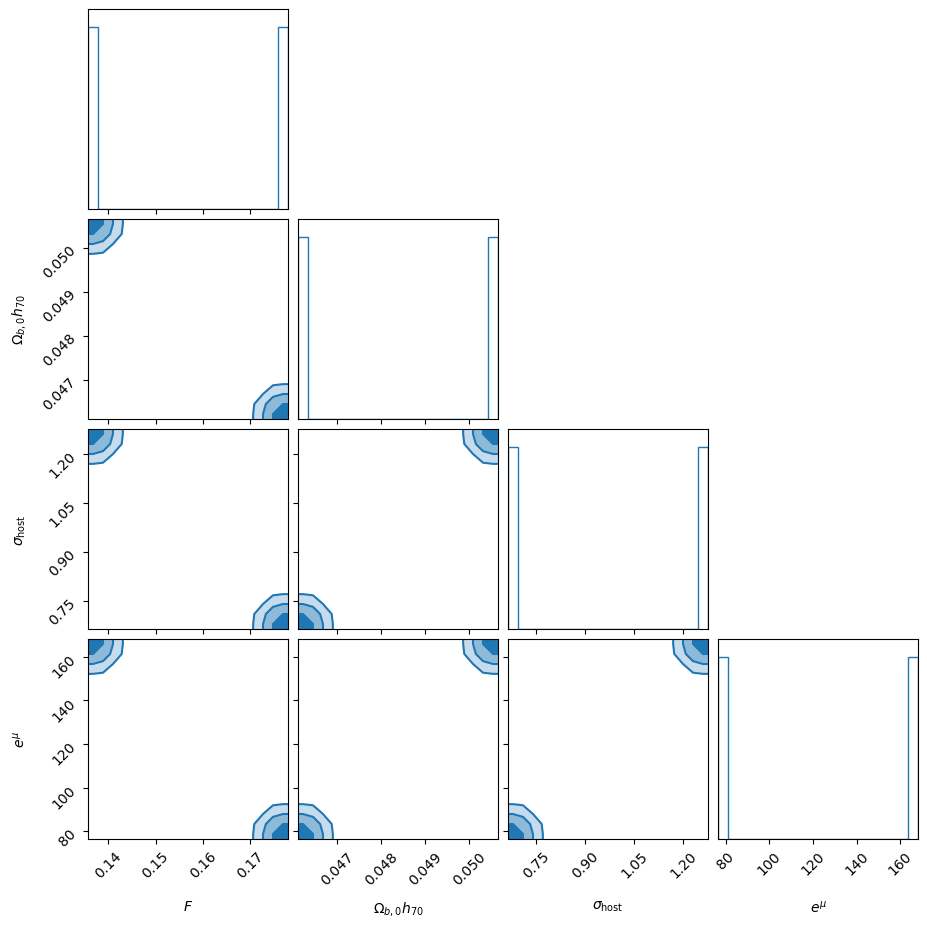

In [46]:
# transfer samples to numpy
inf_data = np.vstack([
    samples['F'],
    samples['O_bh_70'], 
    samples['sigma_host'],
    samples['e_mu']
]).T

# set labels
labels = [r'$F$', r'$\Omega_{b,0}h_{70}$', r'$\sigma_{\rm host}$', r'$e^{\mu}$']

# corner plot
figure = corner.corner(
    inf_data,
    labels=labels,
    smooth=True,
    fill_contours=True,
    color='tab:blue',
    levels=(0.68, 0.95, 0.99)
)

# plt.savefig('corner_plot.png', dpi=300, bbox_inches='tight')